In [1]:
%cd ..

/home/melanie/PycharmProjects/RedundantPrefrontalHemispheres


In [2]:
import matplotlib.pyplot as plt
plt.style.use("stylefile.mplstyle")


# Define colors
colors = {
    "Single": "#333333",
    "Left": "#246EB9",
    "Right": "#8B1E3F",
    "Ipsilateral": "#1B9E77",
    "Contralateral": "#D95F02",
    "Within": "#2B4162",
    
    "Across": "#E89D0B",
    'SerialBiasWeak': '#254441',
    'SerialBias': '#43AA8B',\
    'ReactivationWeak': '#7A8A99',
    'Reactivation': '#12719E',
    'Load2': '#CB9090',
    'Load4': '#883041',
    'Load8': '#131614'
}

from matplotlib.colors import LinearSegmentedColormap
left_right_cmap = LinearSegmentedColormap.from_list("LeftRight",\
                                                     [colors['Left'], "white", colors['Right']])
ipsi_contra_cmap = LinearSegmentedColormap.from_list("IpsiContra",\
                                                     [colors['Ipsilateral'], "white", colors['Contralateral']])
within_cmap = LinearSegmentedColormap.from_list("Within",\
                                                     ["white", colors['Within']])
across_cmap = LinearSegmentedColormap.from_list("Across",\
                                                     ["white", colors['Across']])

In [3]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from cmath import phase
from scipy.stats import circmean, sem
import random
from ast import literal_eval
import seaborn as sns
from scipy.stats import pearsonr
import matplotlib
from scipy.stats import ttest_rel
from scipy import stats

def len2(x):
	if type(x) is not type([]):
		if type(x) is not type(np.array([])):
			return -1
	return len(x)

def phase2(x):
	if not np.isnan(x):
		return phase(x)
	return np.nan

def circdist(angles1,angles2):
    if len2(angles2) < 0:
        if len2(angles1) > 0:
            angles2 = [angles2]*len(angles1)
        else:
            angles2 = [angles2]
            angles1 = [angles1]
        if len2(angles1) < 0:
            angles1 = [angles1]*len(angles2)
    return np.array(list(map(lambda a1,a2: phase2(np.exp(1j*a1)/np.exp(1j*a2)), angles1,angles2)))

def sig_bar(sigs,axis,y,ax,color):
	w=np.diff(axis)[0]
	for s in sigs:
		beg =axis[s]-w/2
		end = axis[s]+w/2
		ax.fill_between([beg,end],[y[0],y[0]],[y[1],y[1]],color=color)
        
def find_nearest(array, value):
    array = np.asarray(array)
    idx = (np.abs(array-value)).argmin()
    return idx

def normgauss(xxx,sigma):
    gauss = (1/(sigma*np.sqrt(2*np.pi)) *np.exp(-(xxx-0)**2 / (2*sigma**2)))
    return gauss/gauss.max()

def normgrad(xxx):
    return np.gradient(xxx)/np.gradient(xxx).max()

def dog1(sigma,x):
    xxx     = np.arange(-2*np.pi, 2*np.pi, .0001) 
    dog_1st = normgrad(normgauss(xxx,sigma))
    return np.array(list(map(lambda x: dog_1st[find_nearest(xxx,x)], x)))

def dog1_scalar(sigma, x):
    gauss = np.exp(-x**2 / (2 * sigma**2))  # peak = 1
    grad = -x / sigma**2 * gauss
    norm_factor = (1 / sigma) * np.exp(-0.5)
    return grad / norm_factor

def mov_avg(rel_loc, err, w1, w2, folded):  
    m_err=[]
    std_err=[]
    count=[]
    cis=[]
    x = np.arange(-np.pi,np.pi,w1)
    if folded:
        err = np.array([np.sign(rel_loc[i])*err[i] if np.sign(rel_loc[i])!=0 else err[i] for i in range(len(err))])
        rel_loc = np.abs(rel_loc)
        x = np.arange(0,np.pi,w1)
    for i,t in enumerate(x):
        idx=abs(circdist(rel_loc,t)) <= w2/2
        m_err.append(np.mean(err[idx]))
        std_err.append(sem(err[idx]))
           
    return (x), np.array(m_err),np.array(std_err)

def decode(angles, firing_rate, N_e):
    R = []
    R = np.sum(np.dot(firing_rate,np.exp(1j*angles)))/N_e
    angle = np.angle(R)
    #if angle < 0:
    #    angle +=2*np.pi
    return angle, np.abs(R) 

def print_stats(a=[], b = [], ttest=ttest_rel, text=''):
    test, pval = ttest(a, b)
    degf = len(a) - 1
    mean_x = np.mean(a - np.array(b))
    se = stats.sem(a - np.array(b))  # standard error of the mean
    ci_low, ci_high = stats.t.interval(0.95, degf, loc=mean_x, scale=se)
    print(text+', '+str(ttest)+': t('+str(degf)+') = '+str(np.round(test, 2))+', p = '+"{:.2e}".format(pval)+\
         ", mean = "+str(np.round(mean_x, 2))+\
         ", 95% CI ["+str(np.round(ci_low,2))+","+str(np.round(ci_high, 2))+"]")
    return


---

In [19]:
loc = './Results_Full/Figure7/'
#loc = './Results/Figure7/'
# where to save figures
PATH = './Figures/Figure7/'

filename = loc + 'HighCapacityModel'

df_models = pd.read_csv(filename+'.csv')

try:
    df_models['stimuli1'] = [literal_eval(df_models['stimuli1'][i]) for i in df_models.index]
    df_models['HEMI1'] = [literal_eval(df_models['HEMI1'][i]) for i in df_models.index]
    df_models['response1bump_area1'] = [literal_eval(df_models['response1bump_area1'][i]) for i in df_models.index]
    df_models['response1bump_area2'] = [literal_eval(df_models['response1bump_area2'][i]) for i in df_models.index]
    df_models['FR_area1'] = [literal_eval(df_models['FR_area1'][i]) for i in df_models.index]
    df_models['FR_area2'] = [literal_eval(df_models['FR_area2'][i]) for i in df_models.index]
    df_models['FR_center1_area1'] = [literal_eval(df_models['FR_center1_area1'][i]) for i in df_models.index]
    df_models['FR_center1_area2'] = [literal_eval(df_models['FR_center1_area2'][i]) for i in df_models.index]
    df_models['bump_average_area1'] = [literal_eval(df_models['bump_average_area1'][i]) for i in df_models.index]
    df_models['bump_average_area2'] = [literal_eval(df_models['bump_average_area2'][i]) for i in df_models.index]
    df_models['time_average'] = [literal_eval(df_models['time_average'][i]) for i in df_models.index]
except KeyError:
    # first time running need to rename some columns
    cols = ['nan1','stimuli1','load',\
            'HEMI1',\
                'FR_area1', 'FR_area2',\
                'FR_center1_area1', 'FR_center1_area2',\
            'response1bump_area1', 'response1_area1', 'responsestrength1_area1',\
             'response1bump_area2', 'response1_area2', 'responsestrength1_area2',\
                'delay1',\
                'stim_start',\
                'stim_duration',\
                'bump_average_area1', 'bump_average_area2',\
                'time_average',\
                'window', 'steps', 'across_factor']
    df_models = df_models.rename(columns={df_models.columns[i]: cols[i] for i in range(len(cols))})

    df_models.drop(['nan1'],axis=1, inplace=True)
    df_models.to_csv(filename+'.csv')
    
    df_models['stimuli1'] = [literal_eval(df_models['stimuli1'][i]) for i in df_models.index]
    df_models['HEMI1'] = [literal_eval(df_models['HEMI1'][i]) for i in df_models.index]
    df_models['FR_area1'] = [literal_eval(df_models['FR_area1'][i]) for i in df_models.index]
    df_models['FR_area2'] = [literal_eval(df_models['FR_area2'][i]) for i in df_models.index]
    df_models['response1bump_area1'] = [literal_eval(df_models['response1bump_area1'][i]) for i in df_models.index]
    df_models['response1bump_area2'] = [literal_eval(df_models['response1bump_area2'][i]) for i in df_models.index]
    df_models['FR_center1_area1'] = [literal_eval(df_models['FR_center1_area1'][i]) for i in df_models.index]
    df_models['FR_center1_area2'] = [literal_eval(df_models['FR_center1_area2'][i]) for i in df_models.index]
    df_models['bump_average_area1'] = [literal_eval(df_models['bump_average_area1'][i]) for i in df_models.index]
    df_models['bump_average_area2'] = [literal_eval(df_models['bump_average_area2'][i]) for i in df_models.index]
    df_models['time_average'] = [literal_eval(df_models['time_average'][i]) for i in df_models.index]



# convert to radians    
df_models['stimuli1_rad'] = [np.deg2rad(df_models.stimuli1[i]) -\
                        (np.deg2rad(df_models.stimuli1[i])>np.pi).astype(int)*2*np.pi\
                            for i in df_models.index]


DoG_SIGMA=0.6


print('# simulations: '+str(len(df_models)))

# simulations: 6000


In [20]:
# TIMINGS

# indexes of bump average (window=200ms, step=100ms)
index_stim1start = int(np.round((df_models.stim_start.unique()[0]/1000)/df_models.steps.unique()[0]))
index_stim1end = int(np.round(((df_models.stim_start.unique()[0]+df_models.stim_duration[0])/1000)/df_models.steps.unique()[0]))

#timings in seconds
time_stim1start = df_models.stim_start.unique()[0]/1000 - df_models.window.unique()[0]
time_stim1end = df_models.stim_start.unique()[0]/1000 + (df_models.stim_duration.unique()[0])/1000 
stim_duration = time_stim1end - time_stim1start

time_end = len(df_models.FR_center1_area1[0])*df_models.steps.unique()[0]
index_end = int(np.round(((time_end))/df_models.steps.unique()[0]))

xxx = np.arange(0, time_end, df_models.steps.unique()[0]) - time_stim1start

### determine responses: How many items are remembered?

In [21]:
import numpy as np

# determine neurons around center index in a wrapped around manner
def circular_range(center, width, N):
    if not np.isnan(center):
        start = int(center - width) % N
        end   = int(center + width) % N
        if start <= end:
            # simple case: no wraparound
            return np.arange(start, end + 1)
        else:
            # wraparound case: concatenate two regions
            return np.concatenate([
                np.arange(start, N),
                np.arange(0, end + 1)
            ])
    else:
        return np.nan


# Get average firing rates across both areas
FR1 = np.vstack(df_models.response1bump_area1)
FR2 = np.vstack(df_models.response1bump_area2)
FR  = (FR1 + FR2) / 2

# determine neural indices for different targets
N_e    = len(df_models.response1bump_area1[0])
angles = np.linspace(0, 2*np.pi, N_e, endpoint=False)
targ_idx = [np.round(np.array(stim) * N_e / (2 * np.pi))for stim in df_models.stimuli1_rad]
width_idx = int(np.deg2rad(30) * N_e / (2 * np.pi))
# get range of neural indices around stimulus locations
target_idxs = [[circular_range(targ_idx[trial][target], width_idx, N_e)\
                for target in range(len(targ_idx[trial]))] for trial in df_models.index]

# define a memory strength cut-off (any below, are given random responses)
memory_cutoff = 0.5

# determine responses for each stimulus location
responsesA, responsesAstrength   = [[] for i in df_models.index], [[] for i in df_models.index]
responsesA1, responsesA1strength = [[] for i in df_models.index], [[] for i in df_models.index]
responsesA2, responsesA2strength = [[] for i in df_models.index], [[] for i in df_models.index]
for trial in df_models.index:
    rA, rA_strength   = [], []
    rA1, rA1_strength = [], []
    rA2, rA2_strength = [], []
    # loop for each presented stimulus (determine all responses)
    for target in range(len(df_models.stimuli1[trial])):
        meanFR1, strengthFR1 = decode(angles[target_idxs[trial][target]],
            FR1[trial, target_idxs[trial][target]],len(target_idxs[trial][target]))
        # if memory strength is weak, assign a random guess
        if strengthFR1 < memory_cutoff:
            meanFR1 = np.random.uniform(-np.pi, np.pi)#np.nan# 
        rA1.append(meanFR1)
        rA1_strength.append(strengthFR1)

        meanFR2, strengthFR2 = decode(angles[target_idxs[trial][target]],
            FR2[trial, target_idxs[trial][target]],  len(target_idxs[trial][target]))
        if strengthFR2 < memory_cutoff:
            meanFR2 = np.random.uniform(-np.pi, np.pi)#np.nan# 
        rA2.append(meanFR2)
        rA2_strength.append(strengthFR2)

        meanFR, strengthFR = decode(angles[target_idxs[trial][target]],
            FR[trial, target_idxs[trial][target]], len(target_idxs[trial][target]))
        if strengthFR < memory_cutoff:
            meanFR = np.random.uniform(-np.pi, np.pi)#np.nan# 
        rA.append(meanFR)
        rA_strength.append(strengthFR)

    responsesA1strength[trial] = rA1_strength
    responsesA2strength[trial] = rA2_strength
    responsesAstrength[trial] = rA_strength
    
    responsesA1[trial] = rA1
    responsesA2[trial] = rA2
    responsesA[trial] = rA

# compute all errors
df_models['errorsA1'] = [circdist(responsesA1[i], df_models.stimuli1_rad[i]) for i in range(len(responsesA1))]
df_models['errors'] = [circdist(responsesA[i], df_models.stimuli1_rad[i]) for i in range(len(responsesA))]

# define which presented stimulus is the target
rng = np.random.default_rng(42) # choose always the same subset of targets
df_models['chosenTarg'] = [rng.integers(len(stim)) for stim in df_models.stimuli1_rad]
df_models['target'] = [df_models.loc[trial, 'stimuli1_rad'][df_models.loc[trial, 'chosenTarg']] for trial in df_models.index]
df_models['error'] = [df_models.loc[trial, 'errors'][df_models.loc[trial, 'chosenTarg']]for trial in df_models.index]

# remove trials with errors larger than 50° (as in the data)
df_models = df_models.loc[np.abs(df_models.error) < np.deg2rad(50)].copy().reset_index(drop=True)

# recompute average firing rates for plotting (to keep indices)
FR1 = np.vstack(df_models.response1bump_area1)
FR2 = np.vstack(df_models.response1bump_area2)
FR  = (FR1 + FR2) / 2

df_models['error_deg'] = np.rad2deg(df_models['error'])

# hemifield of target
df_models['HEMI'] = [df_models.loc[trial, 'HEMI1'][df_models.loc[trial, 'chosenTarg']] for trial in df_models.index]
df_models['hemiload'] = [len(np.where(df_models['HEMI1'][i] == df_models['HEMI'][i])[0]) - 1 for i in df_models.index]

# determine relative locations to non-targets
df_models['rel_locs'] = [circdist(df_models['stimuli1_rad'][i], df_models['target'][i]) for i in df_models.index]
df_models['rel_locs'] = df_models['rel_locs'].apply(lambda lst: [np.nan if x == 0 else x for x in lst])


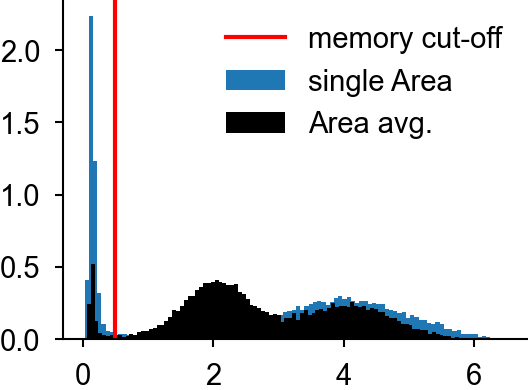

In [22]:
# Visualize strength cut-off for random memory assignment
plt.figure(figsize=(2,1.5))
plt.hist(np.concatenate(responsesA1strength), bins=100, density=True, label='single Area');
plt.hist(np.concatenate(responsesAstrength), bins=100, density=True, color='k', label='Area avg.');
plt.axvline(memory_cutoff, color='r', label='memory cut-off')
plt.legend()

# Sanity checks

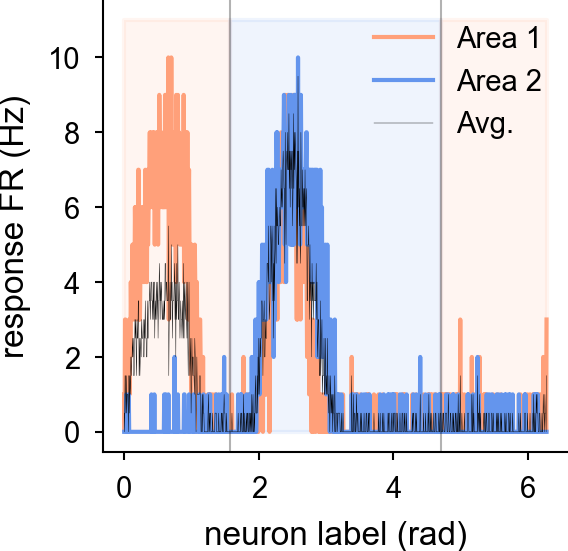

In [23]:
# show an example trial for left area(red), right area (blue) and area average (black)
df_m = df_models.loc[df_models.load==np.unique(df_models.load)[0]]
trial=df_m.index[7]

f, ax = plt.subplots(figsize=(2,2))
plt.plot(angles, FR1[trial], color='lightsalmon', label='Area 1')
plt.plot(angles, FR2[trial], color='cornflowerblue', label='Area 2')
plt.plot(angles, FR[trial], color='k', label='Avg.', lw=0.1)
plt.axvline(np.pi/2,  alpha=0.3, color='k', lw=0.5)
plt.axvline(3*np.pi/2,  alpha=0.3, color='k', lw=0.5)
plt.fill_between([np.pi/2, 3*np.pi/2], [0, 0], [11, 11], color='cornflowerblue', alpha=0.1)
plt.fill_between([0, np.pi/2], [0, 0], [11, 11], color='lightsalmon', alpha=0.1)
plt.fill_between([3*np.pi/2, 2*np.pi], [0, 0], [11, 11], color='lightsalmon', alpha=0.1)
plt.xlabel('neuron label (rad)')
plt.ylabel('response FR (Hz)')
plt.legend()

# Load dependent precision

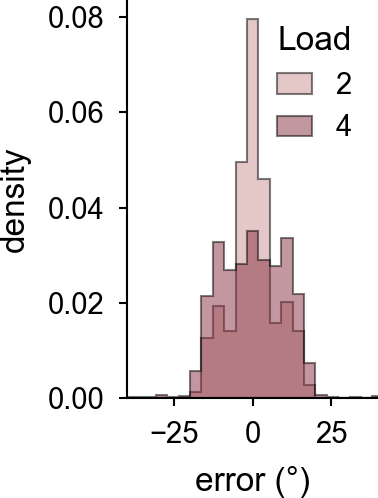

In [24]:
colorsL = ['lightsalmon', 'darkred', 'k']
f, ax = plt.subplots(figsize=(1.5,1.9), sharey=True)
binspace = np.linspace(-180, 180, 100)
for l, load in enumerate(np.unique(df_models.load)):
    plt.hist(df_models.loc[df_models.load==load].error_deg, bins=binspace, color= colors['Load'+str(load)],\
             density=True, label=load, alpha=0.5, histtype='stepfilled',linewidth=0.5,
        edgecolor='k',)

ax.set_xlabel('error (°)')
ax.set_ylabel('density')
ax.legend(title='Load', handlelength=1.2)
ax.set_xlim([-40, 40])
plt.tight_layout()
plt.savefig(PATH+'Multiitem4TargetsCapacityRandom.svg', dpi=300)


# Hemifield specific load dependent precision (Bilateral field advantage)

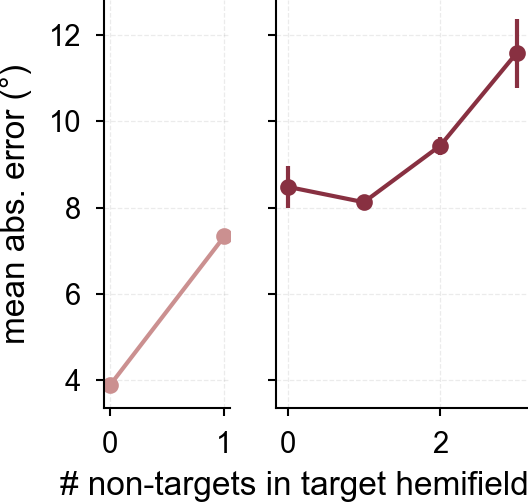

In [25]:
f, ax = plt.subplots(1,2,figsize=(2.,1.77), sharey=True, gridspec_kw={'width_ratios': [0.5, 1]})
colorsL = ['lightsalmon', 'darkred']
for l, load in enumerate(np.unique(df_models.load)):
    df_load = df_models.loc[(df_models.load==load)].copy()
    df_load['error_deg_abs'] = np.abs(df_load.error_deg)

    ax[l].errorbar(df_load.groupby('hemiload').groups.keys(),\
                   df_load.groupby('hemiload').error_deg_abs.mean(),\
                   yerr = df_load.groupby('hemiload').error_deg_abs.sem(), color=colors['Load'+str(load)], marker='o', label = 'load='+str(load))
#nicer ticks
f.text(0.55, 0, '# non-targets in target hemifield', ha='center')
for a in ax:
    a.grid(alpha=0.25)
ax[0].set_ylabel('mean abs. error (°)')
plt.tight_layout()
#plt.savefig(PATH+'Multiitem4RandomLoadPrecision.svg', dpi=300)


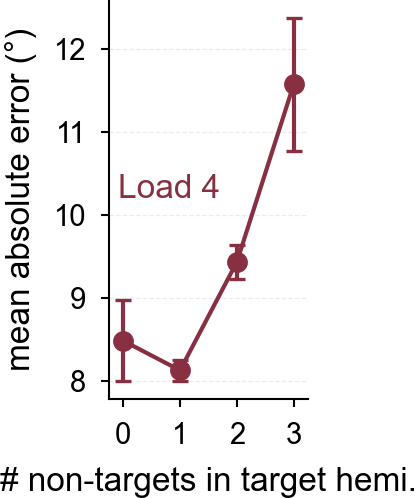

In [26]:
f, ax = plt.subplots(figsize=(1.25,1.9))

df_models['error_deg_abs'] = np.abs(df_models.error_deg)

df_multiitem = df_models.loc[df_models.load==np.unique(df_models.load)[1]]

precision = df_multiitem.groupby('hemiload').error_deg_abs
means = precision.mean()
errors = precision.sem()
ax.errorbar(
    np.unique(df_multiitem.hemiload),
    means,
    yerr=errors,
    color=colors['Load4'],
    marker='o',
    markersize=4,
    linewidth=1.0,
    capsize=2,
    capthick=0.8
)

ax.set_xlabel('# non-targets in target hemi.')
ax.set_ylabel('mean absolute error (°)')
ax.set_xlim(-0.25, 3.25)
ax.set_xticks([0,1,2,3])
ax.text(-.1, 10.2, 'Load 4', color=colors['Load4'])
ax.grid(axis='y', alpha=0.25, linewidth=0.3)
plt.tight_layout()
#plt.savefig(PATH+'Multiitem4RandomBFA.svg', dpi=300)


PROBLEM: In the unilateral condition, relative distances are much smaller. The peak of my distraction is at fairly small angles (unlike in the data). This leads to the standarddeviation struggling 

# Distractability

In [12]:
import statsmodels.formula.api as smf
sigma = 0.65
print('Fit sigma is '+str(sigma))

#############################
### Get optimal sigma fit ###
#############################

# df_helper = df_models.copy()
# sfit = []
# sigmas = np.arange(0.1, 2, 0.05)
# for s in sigmas:
    
#     # for ach sigma determine the strongest distractor
#     df_helper['expectedAttractions'] = [[-dog1_scalar(sigma, df_helper.rel_locs[trial][targ])\
#                                       for targ in range(len(df_helper.rel_locs[trial]))] \
#                                      for trial in df_helper.index]
#     strongest_distr = [np.nanargmax(np.abs(df_helper['expectedAttractions'][i])) for i in df_helper.index]
#     df_helper['strongestDistr_ID'] = strongest_distr
#     df_helper['rel_loc'] = [df_helper['rel_locs'][i][strongest_distr[iidx]] for iidx, i in enumerate(df_helper.index)]

#     # fit model to get BIC
#     df_helper['DoG'] = -dog1(s, df_helper.rel_loc)
#     M_all = smf.ols('error ~ DoG', data=df_helper).fit()
#     sfit.append(M_all.bic)
    
# plt.plot(sigmas, sfit)
# sigma = sigmas[np.argmin(sfit)]
# print(sigmas[np.argmin(sfit)])

Fit sigma is 0.65


### determine expected attraction

In [13]:
df_models['expectedAttractions'] = [[-dog1_scalar(sigma, df_models.rel_locs[trial][targ])\
                                      for targ in range(len(df_models.rel_locs[trial]))] \
                                     for trial in df_models.index]

strongest_distr = [np.nanargmax(np.abs(df_models['expectedAttractions'][i])) for i in df_models.index]

# distance to strongest distractor
df_models['strongestDistr_ID'] = strongest_distr
df_models['rel_loc'] = [df_models['rel_locs'][i][strongest_distr[iidx]] for iidx, i in enumerate(df_models.index)]
df_models['strongestHemi'] = [df_models['HEMI1'][i][strongest_distr[iidx]] for iidx, i in enumerate(df_models.index)]
df_models['withinAcross'] = df_models['HEMI'] == df_models['strongestHemi']

# Attraction towards strongest non-target

/home/melanie/anaconda3/envs/brian2/lib/python3.6/site-packages/numpy/core/fromnumeric.py:3373: RuntimeWarning: Mean of empty slice.
  out=out, **kwargs)
/home/melanie/anaconda3/envs/brian2/lib/python3.6/site-packages/numpy/core/_methods.py:170: RuntimeWarning: invalid value encountered in double_scalars
  ret = ret.dtype.type(ret / rcount)
/home/melanie/anaconda3/envs/brian2/lib/python3.6/site-packages/numpy/core/_methods.py:234: RuntimeWarning: Degrees of freedom <= 0 for slice
  keepdims=keepdims)
/home/melanie/anaconda3/envs/brian2/lib/python3.6/site-packages/numpy/core/_methods.py:195: RuntimeWarning: invalid value encountered in true_divide
  arrmean, rcount, out=arrmean, casting='unsafe', subok=False)
/home/melanie/anaconda3/envs/brian2/lib/python3.6/site-packages/numpy/core/_methods.py:226: RuntimeWarning: invalid value encountered in double_scalars
  ret = ret.dtype.type(ret / rcount)
/home/melanie/anaconda3/envs/brian2/lib/python3.6/site-packages/numpy/core/fromnumeric.py:337

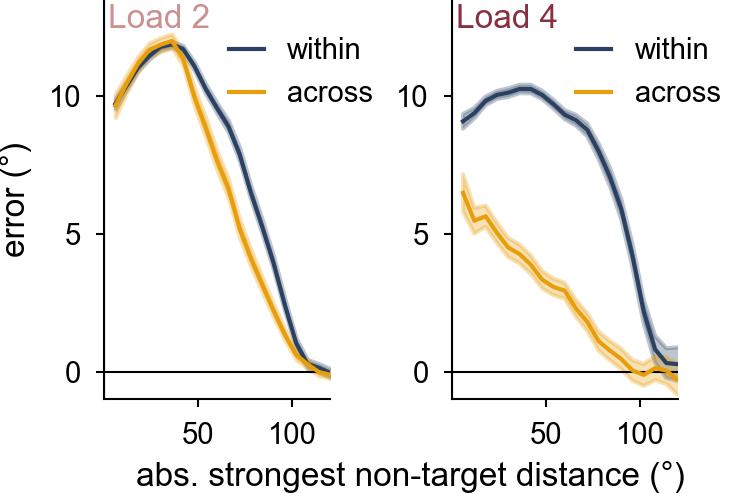

In [14]:
w1=np.pi/30
w2=np.pi/3
folded=True

movavgWithin, movavgAcross = {l: [] for l in np.unique(df_models.load)}, {l: [] for l in np.unique(df_models.load)}
movstdWithin, movstdAcross = {l: [] for l in np.unique(df_models.load)}, {l: [] for l in np.unique(df_models.load)}
fit_within,fit_across = {l: [] for l in np.unique(df_models.load)}, {l: [] for l in np.unique(df_models.load)}
fit_within_bse,fit_across_bse = {l: [] for l in np.unique(df_models.load)}, {l: [] for l in np.unique(df_models.load)}
fit_all = {l: [] for l in np.unique(df_models.load)}

# for each load determine non-target attraction
for lidx, load in enumerate(np.unique(df_models.load)):
    df_helper = df_models.loc[df_models.load==load].copy()

    # split trials for when the strongest non-target was within or across hemifields
    df_within = df_helper.loc[df_helper.withinAcross==True].copy()
    df_across = df_helper.loc[df_helper.withinAcross==False].copy()

    # determine the moving average
    xx, m_err, std_err = mov_avg(df_within['rel_loc'].values, df_within['error'].values, w1, w2, folded)
    movavgWithin[load] = (m_err)
    movstdWithin[load] = (std_err)

    xx, m_err, std_err = mov_avg(df_across['rel_loc'].values, df_across['error'].values, w1, w2, folded)
    movavgAcross[load] = (m_err)
    movstdAcross[load] = (std_err)
    
    # fit model
    df_within['DoG'] = -dog1(sigma, df_within.rel_loc)
    M = smf.ols('error ~ DoG', data=df_within).fit()
    fit_within[load] = np.rad2deg(M.params['DoG'])
    fit_within_bse[load] = np.rad2deg(M.bse['DoG'])
    
    df_across['DoG'] = -dog1(sigma, df_across.rel_loc)
    M = smf.ols('error ~ DoG', data=df_across).fit()
    fit_across[load] = np.rad2deg(M.params['DoG'])
    fit_across_bse[load] = np.rad2deg(M.bse['DoG'])
    
    df_helper['DoG'] = -dog1(sigma, df_helper.rel_loc)
    M = smf.ols('error ~ DoG', data=df_helper).fit()
    fit_all[load] = np.rad2deg(M.params['DoG'])

# PLOT
f, ax = plt.subplots(1,2,figsize=(2.6,1.74), sharex=True)
for lidx, load in enumerate(np.unique(df_models.load)):
    ax[lidx].axhline(0, color='k', lw=0.5)
    ax[lidx].axvline(0, color='k', lw=0.5)
    
    mean = np.rad2deg(movavgWithin[load])
    CI = np.rad2deg(movstdWithin[load])
    ax[lidx].plot(np.rad2deg(xx), mean, color=colors['Within'], label='within', lw=1)
    ax[lidx].fill_between(np.rad2deg(xx), mean - CI, mean + CI, alpha=0.3, color=colors['Within'])
    
    mean = np.rad2deg(movavgAcross[load])
    CI = np.rad2deg(movstdAcross[load])
    ax[lidx].plot(np.rad2deg(xx), mean, color=colors['Across'], label='across', lw=1)
    ax[lidx].fill_between(np.rad2deg(xx), mean - CI, mean + CI, alpha=0.3, color=colors['Across'])
    
    ax[lidx].legend(handlelength=1.2, loc=(0.5,0.7))
    ax[lidx].text(2, 12.5, 'Load '+str(load), color=colors['Load'+str(load)])
    ax[lidx].set_xlim([0, 120])
    ax[lidx].set_ylim([-1, 13.5])
    ax[lidx].set_yticks([0,5,10])
ax[0].set_ylabel('error (°)')
ax[0].set_xticks([50, 100])
f.text(0.22, 0, 'abs. strongest non-target distance (°)')

plt.tight_layout()
#plt.savefig(PATH+'ModelAttractionWA.svg', dpi=300, bbox_inches='tight')


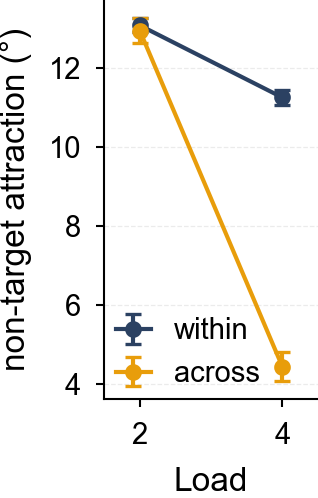

In [15]:
# PLOT MODEL FITS FOR EASIER QUANTIFICATION
from scipy.stats import ttest_ind
f, ax = plt.subplots(figsize=(1.3,1.9))
ax.errorbar([2,4],\
             [fit_within[2], fit_within[4]],\
            yerr = [fit_within_bse[2], fit_within_bse[4]],\
             label='within', marker='o', color=colors['Within'], capsize=2,
    capthick=0.8)
ax.errorbar([2, 4],\
             [fit_across[2], fit_across[4]],\
             yerr = [fit_across_bse[2], fit_across_bse[4]],\
             label='across', marker='o', color=colors['Across'], capsize=2,
    capthick=0.8)

ax.set_xlim([1.5, 4.5])
ax.set_ylabel('non-target attraction (°)')
ax.legend(handlelength=1.2, loc=(0,0))
ax.set_xlabel('Load')
ax.grid(axis='y', alpha=0.25, linewidth=0.3)
plt.tight_layout()
#plt.savefig(PATH+'ModelAttractionWA_stats.svg', dpi=300)


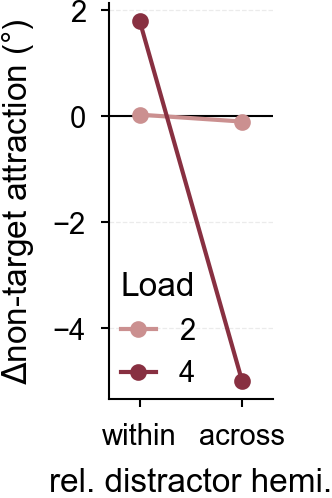

In [16]:
from scipy.stats import ttest_ind
f, ax = plt.subplots(figsize=(1.15,1.9))
ax.axhline(0, color='k', lw=0.5)
for l, load in enumerate(np.unique(df_models.load)):
    ax.errorbar([0, 1],\
                 [fit_within[load] - fit_all[load], fit_across[load] - fit_all[load]],\
                 label=load, marker='o', color=colors['Load'+str(load)], capsize=2,
        capthick=0.8)

#ax.text(0, 3.8, 'n.s.', fontsize=10, horizontalalignment='center')
#ax.text(1, 3.7, '*', fontsize=10, horizontalalignment='center')
ax.set_ylabel('$\Delta$non-target attraction (°)')
ax.legend(loc=(0,0),title='Load',  handlelength=1.2)
ax.set_xticks([0,1])
ax.set_xlim([-0.3, 1.3])
#ax.set_ylim([-1, 4.2])
ax.set_xticklabels(['within', 'across'])
ax.set_xlabel('rel. distractor hemi.')
ax.grid(axis='y', alpha=0.25, linewidth=0.3)
plt.tight_layout()
#plt.savefig(PATH+'ModelAttractionLoad_stats.svg', dpi=300)


## Supplement: Compare contralateral decoder strength for an additional item added within vs across hemifields (Buschmann 2011, Matsushima 2014)



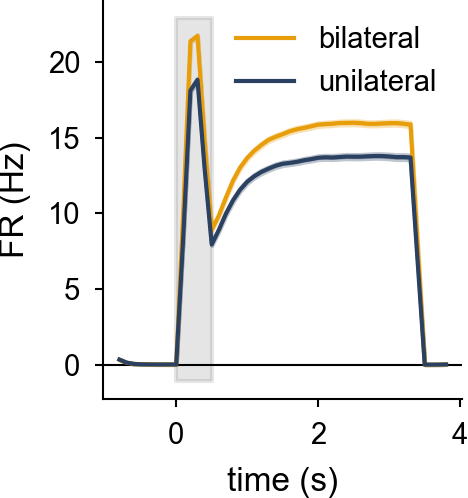

In [17]:
df2 = df_models.loc[(df_models.load==2)].copy()
# contralateral trials to area 1
df2['h1'] = [h[0] for h in df2.HEMI1]
df2['h2'] = [h[1] for h in df2.HEMI1]
df2 = df2.loc[df2.h1 == 1]

df2_unilateral = df2.loc[df2.h1==df2.h2]
df2_bilateral = df2.loc[df2.h1!=df2.h2]

f, ax = plt.subplots(figsize=(1.8,1.9))
FR_unilateral = np.mean([np.array(df2_unilateral.FR_center1_area1[i]) for i in df2_unilateral.index], axis=0)
CI_unilateral = sem([np.array(df2_unilateral.FR_center1_area1[i]) for i in df2_unilateral.index], axis=0)
FR_bilateral = np.mean([np.array(df2_bilateral.FR_center1_area1[i]) for i in df2_bilateral.index], axis=0)
CI_bilateral = sem([np.array(df2_bilateral.FR_center1_area1[i]) for i in df2_bilateral.index], axis=0)
plt.axhline(0, lw=0.5, color='k')
plt.fill_between(xxx, FR_bilateral-CI_bilateral, FR_bilateral + CI_bilateral,\
                 alpha=0.3,  color=colors['Across'])
plt.plot(xxx, FR_bilateral, label='bilateral', color=colors['Across'])
plt.fill_between(xxx, FR_unilateral-CI_unilateral, FR_unilateral+CI_unilateral,\
                 alpha=0.3, color=colors['Within'])
plt.plot(xxx, FR_unilateral, label='unilateral', color=colors['Within'])

y0, y1 = ax.get_ylim()
plt.fill_between([0, stim_duration], y0, y1, color='grey', alpha=0.2)
plt.xlabel('time (s)')
plt.ylabel('FR (Hz)')
plt.legend()
plt.tight_layout()
#plt.savefig(PATH+'Multiitem3FRUniVSBilateral.svg', dpi=300)
